# 📊 Visualisation des Données  

Dans ce notebook, nous analysons et affichons **graphiquement** les caractéristiques des images.  
Nous allons explorer :  
✅ La distribution des **formats d'images**  
✅ L'orientation des **images (portrait/paysage)**  
✅ La répartition des **couleurs dominantes**  


## 📦 Installation des dépendances  
Nous installons `seaborn` pour améliorer la visualisation des données.
```
pip install seaborn
```

## 📸 Distribution des Formats d'Images  
Ce graphique montre combien d'images existent pour chaque format (`JPEG`, `PNG`, etc.).
Cela nous aide à comprendre la diversité des images utilisées.

## Chargement des métadonnées

Les métadonnées des images sont stockées dans le fichier `annotations.json`.  
Elles contiennent :
- Le format de l'image (`JPEG`, `PNG`, etc.).
- Les dimensions de l'image.
- L'orientation de l'image (`portrait` ou `paysage`).
- Les couleurs dominantes.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ANNOTATION_FILE = "../data_collection/annotations.json"

# Chargement des données
try:
    with open(ANNOTATION_FILE, "r") as f:
        data = json.load(f)
    print("Fichier chargé avec succès.")
except FileNotFoundError:
    print(f"Erreur : Le fichier {ANNOTATION_FILE} est introuvable.")
    data = {}

# Transformation des données en DataFrame
df = pd.DataFrame([
    {
        "image": img,
        "format": details["metadata"]["format"],
        "size_x": details["metadata"]["size"][0],
        "size_y": details["metadata"]["size"][1],
        "orientation": "portrait" if details["metadata"]["size"][1] > details["metadata"]["size"][0] else "landscape",
        "colors": details["dominant_colors"]
    }
    for img, details in data.items()
])

df.head()

Fichier chargé avec succès.


,image,format,size_x,size_y,orientation,colors
0,Aerial%20view%20of%20Krasnoyarsk%201.jpg,JPEG,2272,1704,landscape,"[#7f8080, #3f3c2e, #cbd2d7]"
1,Asmara2.jpg,JPEG,1024,683,landscape,"[#baa180, #3b3226, #6b6766]"
2,Bahrain%20World%20trade%20Center%20.jpg,JPEG,2048,1365,landscape,"[#8c7888, #382f3a, #485990]"
3,Boston%20Financial%20District%20skyline.jpg,JPEG,2196,1680,landscape,"[#4f96d2, #3b4750, #c2c8ce]"
4,Marcus%20Aurelius%20Arch%20Tripoli%20Libya.jpg,JPEG,2048,1536,landscape,"[#40402e, #e1deda, #8a8575]"


## Distribution des formats d'images

Ce graphique affiche la répartition des formats d'images dans l'ensemble de données.

C:\Users\cmvil\AppData\Local\Temp\ipykernel_47892\471217939.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["format"].value_counts().index, y=df["format"].value_counts().values, palette="Blues")


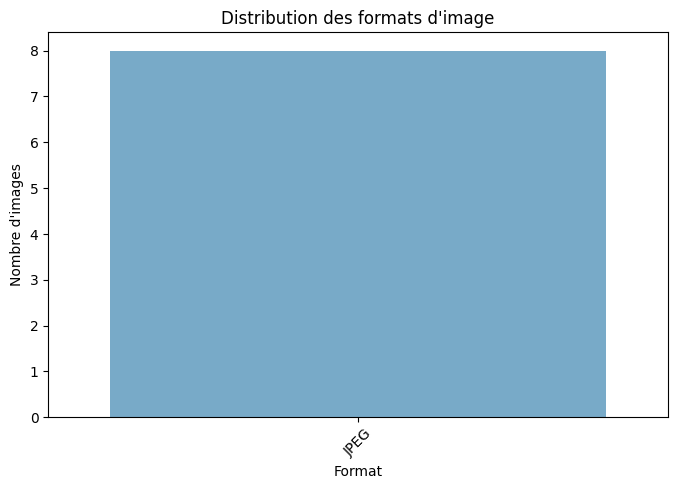

In [2]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df["format"].value_counts().index, y=df["format"].value_counts().values, palette="Blues")
plt.title("Distribution des formats d'image")
plt.xlabel("Format")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=45)
plt.show()


## Orientation des images

Ce graphique montre la répartition entre les images en mode `portrait` et `paysage`.


C:\Users\cmvil\AppData\Local\Temp\ipykernel_47892\3674205921.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["orientation"].value_counts().index, y=df["orientation"].value_counts().values, palette=["gray", "orange"])
C:\Users\cmvil\AppData\Local\Temp\ipykernel_47892\3674205921.py:2: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.barplot(x=df["orientation"].value_counts().index, y=df["orientation"].value_counts().values, palette=["gray", "orange"])


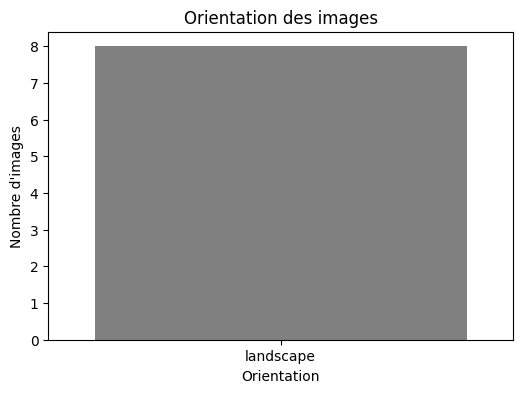

In [3]:
plt.figure(figsize=(6, 4))
sns.barplot(x=df["orientation"].value_counts().index, y=df["orientation"].value_counts().values, palette=["gray", "orange"])
plt.title("Orientation des images")
plt.xlabel("Orientation")
plt.ylabel("Nombre d'images")
plt.show()


## Répartition des couleurs dominantes

Nous affichons ici les couleurs les plus fréquentes parmi toutes les images.


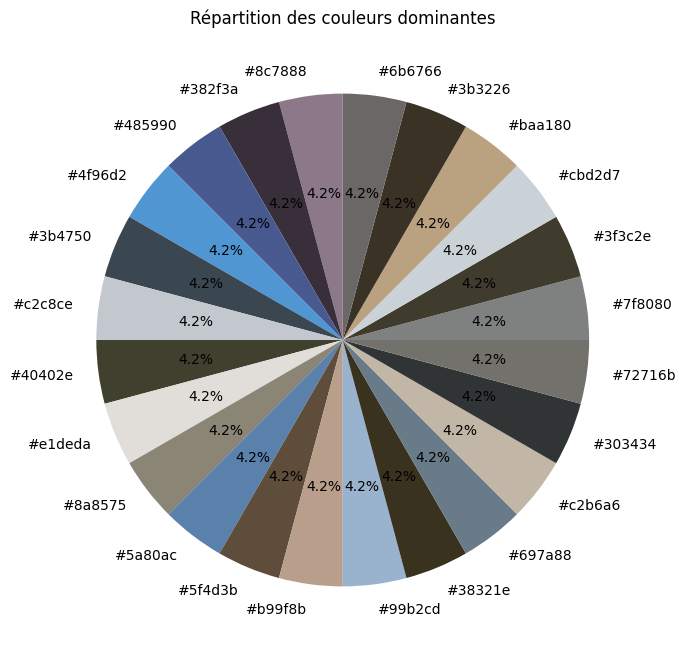

In [4]:
color_counts = {}

for colors in df["colors"]:
    for color in colors:
        color_counts[color] = color_counts.get(color, 0) + 1

plt.figure(figsize=(8, 8))
plt.pie(color_counts.values(), labels=color_counts.keys(), colors=color_counts.keys(), autopct="%1.1f%%")
plt.title("Répartition des couleurs dominantes")
plt.show()
